# MLP Exercises Notebook

Built from `exercises/mlp.md`. Each exercise includes:
- a visible prompt cell,
- one empty student code cell,
- one hidden reference solution/explanation markdown cell.

### Part 1: Data and Context Dataset

**Exercise 1: Imports and Dataset Loading**  
Write code to:
- Import `torch`, `torch.nn.functional as F`, and `matplotlib.pyplot as plt`.
- Enable inline plotting for notebooks.
- Read the `names.txt` file and put all names in a Python list.
- Inspect the first few names and the total number of names.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

bands = open('data/band_names.txt').read().splitlines()

<details><summary>Reference solution (hidden)</summary>

This initializes the core libraries, loads the names corpus, and verifies both a sample and dataset size to ensure file loading is correct.

```python
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
words[:8]
len(words)
```
</details>

**Exercise 2: Character Vocabulary and Mappings**  
Build a character-level vocabulary:
- Collect all unique characters in the dataset.
- Sort them and construct two dictionaries:
  - `stoi`: maps each character to an integer index, reserving `0` for the special `'.'` token.
  - `itos`: inverse mapping from index to character.
- Print `itos` to verify the mapping.

In [2]:
chars = sorted(list(set(''.join(bands))))

stoi = {s : i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i : s for s, i in stoi.items()}

n_chars = len(stoi)

<details><summary>Reference solution (hidden)</summary>

This creates deterministic index mappings for all characters and reserves index `0` for the boundary token `.` used in context windows.

```python
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)
```
</details>

**Exercise 3: Building the (Context, Next-Char) Dataset**  
Create a dataset of fixed-length contexts and next characters:
- Set `block_size = 3` (three characters of context).
- For every word `w` in `words`, iterate through `w + '.'` while maintaining a rolling context of length 3, initialized as `[0, 0, 0]`.
- For each character, append the current context to a list `X` and the current character index to a list `Y`, then update the context by cropping and appending the new index.
- Convert `X` and `Y` to `torch.tensor` objects and inspect their shapes and dtypes.

In [34]:
block_size = 3

X = []
Y = []

for band in bands:
    ctx = block_size*[0]
    for ch in band + '.':
        #ctx_text = ''
        #for c in ctx:
            #ctx_text += itos[c]
        #print(f'{ctx_text} --> {ch}')
        ix = stoi[ch]
        X.append(ctx)
        Y.append(ix)
        ctx = ctx[1:] + [ix]         

X = torch.tensor(X)
Y = torch.tensor(Y)

<details><summary>Reference solution (hidden)</summary>

The rolling context converts each word into supervised examples where each 3-token context predicts the next character token.

```python
block_size = 3
X, Y = [], []
for w in words:
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, X.dtype, Y.shape, Y.dtype
```
</details>

### Part 2: Tiny Embedding and One Hidden Layer

**Exercise 4: Character Embedding Table (2D)**  
Introduce a small embedding table:
- Create a tensor `C` of shape `(27, 2)` initialized with random values.
- Use integer indexing with `X` to obtain `emb = C[X]`.
- Inspect the shape of `emb` and confirm it is `(num_examples, 3, 2)`.

In [35]:
g = torch.Generator().manual_seed(5390438945)
C = torch.randn((n_chars,2), requires_grad=True, generator=g)
emb = C[X]
emb.shape

torch.Size([1698882, 3, 2])

<details><summary>Reference solution (hidden)</summary>

Embedding lookup maps integer tokens to dense vectors and preserves the original context axes.

```python
C = torch.randn((27, 2))
emb = C[X]
emb.shape
```
</details>

**Exercise 5: Hidden Layer and tanh Nonlinearity**  
Build a single hidden layer on top of the embeddings:
- Create weights `W1` of shape `(6, 100)` and biases `b1` of shape `(100,)` using random initialization.
- Flatten the last two dimensions of `emb` into shape `(-1, 6)` using `.view` and compute hidden activations `h = torch.tanh(emb.view(-1, 6) @ W1 + b1)`.
- Inspect `h` and its shape to verify it is `(num_examples, 100)`.

In [36]:
W1 = torch.randn((6,100), requires_grad=True, generator=g)
b1 = torch.randn((100,), requires_grad=True, generator=g)

# broadcasting check
# 6, 100
# 1, 100 -- 100 biases get copied horizontally (along dim 0), so each neuron has it's own

In [37]:
# inneficient way: inp = torch.cat(torch.unbind(emb, 1),1)
inp = emb.view(-1, 6)
inp.shape

torch.Size([1698882, 6])

In [38]:
h = torch.tanh(inp @ W1 + b1)
h.shape

torch.Size([1698882, 100])

<details><summary>Reference solution (hidden)</summary>

This concatenates 3 embeddings via `.view(-1, 6)`, applies an affine transform, then nonlinearity (`tanh`) for hidden features.

```python
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h
h.shape
```
</details>

**Exercise 6: Output Layer, Softmax, and Manual NLL Loss**  
Complete the forward pass for a shallow MLP on a small batch:
- Define `W2` with shape `(100, 27)` and `b2` with shape `(27,)`.
- Compute `logits = h @ W2 + b2` and inspect its shape.
- Turn `logits` into probabilities:
  - `counts = logits.exp()`
  - `prob = counts / counts.sum(1, keepdims=True)`
- For the first 32 examples, compute the negative log-likelihood loss:
  - Index the probabilities of the correct next character using `prob[torch.arange(32), Y[:32]]`.
  - Take `log`, negate, and average to obtain a scalar `loss`.

In [39]:
W2 = torch.randn((100,n_chars), requires_grad=True, generator=g)
b2 = torch.randn((n_chars,), requires_grad=True, generator=g)

In [40]:
logits = h @ W2 + b2 
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(X.shape[0]),Y].log().mean()
loss

tensor(22.4962, grad_fn=<NegBackward0>)

In [41]:
F.cross_entropy(logits, Y)

tensor(22.4962, grad_fn=<NllLossBackward0>)

<details><summary>Reference solution (hidden)</summary>

The output layer produces logits over 27 characters; exponentiation + normalization yields probabilities, and indexed log-probability gives NLL.

```python
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
logits = h @ W2 + b2
logits.shape
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape
loss = -prob[torch.arange(32), Y[:32]].log().mean()
loss
```
</details>

### Part 3: Train / Dev / Test Split and Dataset Helper

**Exercise 7: Dataset Builder Function**  
Refactor dataset creation into a reusable function:
- Keep `block_size` and the `stoi/itos` mappings from earlier.
- Implement a function `build_dataset(words)` that:
  - Builds lists `X` and `Y` using the same context-rolling logic as in Exercise 3.
  - Converts them to tensors, prints their shapes, and returns `(X, Y)`.

In [ ]:
## done

<details><summary>Reference solution (hidden)</summary>

Factoring dataset logic into a function lets you reuse the exact same preprocessing for train/dev/test splits.

```python
block_size = 3
def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y
```
</details>

**Exercise 8: Shuffling and Splitting Words**  
Create the standard 80/10/10 train-dev-test split:
- Set a Python `random` seed for reproducibility.
- Shuffle the list `words` in-place.
- Compute indices `n1 = int(0.8 * len(words))` and `n2 = int(0.9 * len(words))`.
- Build three datasets using `build_dataset`:
  - `Xtr, Ytr = build_dataset(words[:n1])`
  - `Xdev, Ydev = build_dataset(words[n1:n2])`
  - `Xte, Yte = build_dataset(words[n2:])`

In [361]:
block_size = 4

def build_dataset(words):
    X, Y = [], []
    for word in words: 
        ctx = block_size*[0]
        for ch in word + '.':
            ix = stoi[ch]
            X.append(ctx)
            Y.append(ix)
            ctx = ctx[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(bands)

n1 = int(0.8 * len(bands))
n2 = int(0.9 * len(bands))

Xtr, Ytr = build_dataset(bands[:n1])
Xdev, Ydev = build_dataset(bands[n1:n2])
Xte, Yte = build_dataset(bands[n2:])

<details><summary>Reference solution (hidden)</summary>

This creates reproducible train/dev/test splits on words, then expands each split into token-level `(X, Y)` examples.

```python
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])
Xtr.shape, Ytr.shape
```
</details>

### Part 4: Respectable MLP: Parameters and Training Loop

**Exercise 9: Model Parameters and Counting Them**  
Move to the final network architecture used in the video:
- Create a `torch.Generator` with a fixed manual seed.
- Initialize the parameters:
  - `C` of shape `(27, 10)`
  - `W1` of shape `(30, 200)`
  - `b1` of shape `(200,)`
  - `W2` of shape `(200, 27)`
  - `b2` of shape `(27,)`
- Put all of them into a list `parameters`.
- Compute and print the total number of parameters using `sum(p.nelement() for p in parameters)`.

In [376]:
g = torch.Generator().manual_seed(5390438945)

# parameters
n_embeds = 12
n_hidden = 350

# 12 / 350 already pretty good with 64 bs


# embeddings
C = torch.randn((n_chars,n_embeds), requires_grad=True, generator = g)

# hidden layer
W1 = torch.randn((n_embeds*block_size, n_hidden), requires_grad=True, generator=g)
b1 = torch.randn(n_hidden, requires_grad=True, generator=g)

# output layer
W2 = torch.randn((n_hidden, n_chars), requires_grad=True, generator=g)
b2 = torch.randn(n_chars, requires_grad=True, generator=g)

parameters = [C, W1, b1, W2, b2]
n_params = sum(p.nelement() for p in parameters)
n_params

40382

<details><summary>Reference solution (hidden)</summary>

This initializes the full MLP used later for training: embedding table, hidden layer, output layer, and parameter list.

```python
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters)
```
</details>

**Exercise 10: Enabling Gradients and Learning-Rate Range**  
Prepare for gradient-based training:
- Loop over all `parameters` and set `p.requires_grad = True`.
- Create a logarithmically spaced learning-rate range for exploration:
  - `lre = torch.linspace(-3, 0, 1000)`
  - `lrs = 10**lre`
- Create empty lists to track training statistics: `lri`, `lossi`, `stepi`.

In [377]:
n_steps = 400000
batch_size = 64
lre = torch.linspace(-3, 0, n_steps)
lrs = 10**lre

lri = []
lossi = []
stepi = torch.arange(0,n_steps).tolist()

In [378]:
for i in range(n_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, n_embeds*block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    if i % 1000 == 0: 
        print(f'{i} : {loss.item()}')

    # backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < n_steps/2 else 0.01
    #lr = lrs[i]
    #lr = 0.001
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())


0 : 38.734596252441406
1000 : 6.731314182281494
2000 : 2.9134092330932617
3000 : 3.3428633213043213
4000 : 3.2209184169769287
5000 : 3.1912829875946045
6000 : 3.2750308513641357
7000 : 3.1862471103668213
8000 : 3.4658854007720947
9000 : 3.260413408279419
10000 : 3.758894443511963
11000 : 3.3940956592559814
12000 : 3.16408109664917
13000 : 3.6646108627319336
14000 : 3.150484561920166
15000 : 2.7142088413238525
16000 : 2.4361703395843506
17000 : 2.6888442039489746
18000 : 2.4164745807647705
19000 : 2.590139150619507
20000 : 3.1171798706054688
21000 : 2.6476290225982666
22000 : 2.9775872230529785
23000 : 2.659252882003784
24000 : 2.484257936477661
25000 : 2.905841827392578
26000 : 2.602681875228882
27000 : 2.7225117683410645
28000 : 2.8594770431518555
29000 : 2.489818572998047
30000 : 2.7901551723480225
31000 : 2.6341094970703125
32000 : 2.544276475906372
33000 : 3.338878870010376
34000 : 2.8793251514434814
35000 : 2.674006938934326
36000 : 2.578476667404175
37000 : 2.8739352226257324
380

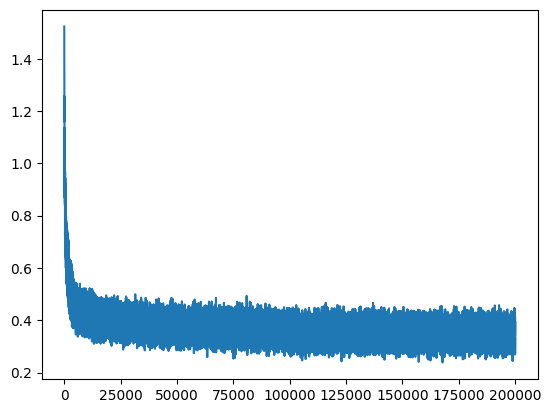

In [198]:
plt.plot(torch.arange(0,len(lossi)), lossi)

In [379]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, n_embeds*block_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

2.201185941696167


In [380]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, n_embeds*block_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.233292579650879


In [381]:
emb = C[Xte]
h = torch.tanh(emb.view(-1, n_embeds*block_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
print(loss.item())

2.232260227203369


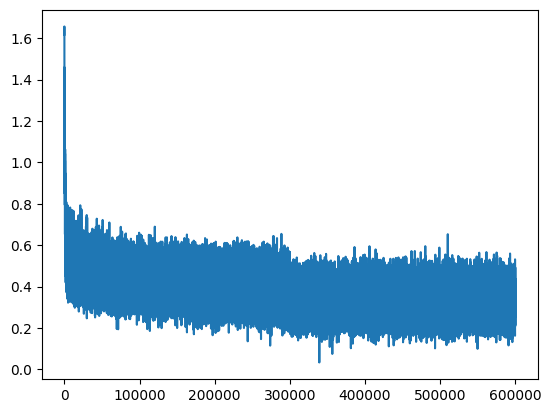

In [353]:
plt.plot(stepi, lossi)

<details><summary>Reference solution (hidden)</summary>

Gradients must be enabled before backprop; logarithmic LR candidates are useful for learning-rate search experiments.

```python
for p in parameters:
  p.requires_grad = True
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lri = []
lossi = []
stepi = []
```
</details>

**Exercise 11: Mini-batch Training Loop with LR Schedule**  
Implement the main training loop:
- For 200,000 iterations:
  - Sample a mini-batch of indices `ix` of size 32 from the range `[0, Xtr.shape[0])`.
  - Forward pass:
    - `emb = C[Xtr[ix]]` (shape `(32, 3, 10)`).
    - `h = torch.tanh(emb.view(-1, 30) @ W1 + b1)` (shape `(32, 200)`).
    - `logits = h @ W2 + b2` (shape `(32, 27)`).
    - `loss = F.cross_entropy(logits, Ytr[ix])`.
  - Backward pass:
    - Zero all gradients by setting `p.grad = None` for each `p` in `parameters`.
    - Call `loss.backward()`.
  - Parameter update with a piecewise-constant learning rate:
    - Use `lr = 0.1` for the first 100,000 steps and `lr = 0.01` afterwards.
    - Update each parameter with `p.data += -lr * p.grad`.
  - Append the iteration index and `loss.log10().item()` to `stepi` and `lossi` respectively.

In [ ]:
# done

<details><summary>Reference solution (hidden)</summary>

This is the full SGD loop: random mini-batches, forward pass, cross-entropy objective, gradient reset, backprop, scheduled LR update, and logging.

```python
for i in range(200000):
  ix = torch.randint(0, Xtr.shape[0], (32,))
  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  stepi.append(i)
  lossi.append(loss.log10().item())
```
</details>

### Part 5: Evaluation, Visualization, and Sampling

**Exercise 12: Plotting Training Loss**  
Visualize how the loss evolves:
- Use `plt.plot(stepi, lossi)` to plot the log10-loss over training steps.

In [ ]:
# done

<details><summary>Reference solution (hidden)</summary>

A quick training diagnostic to inspect optimization trend and noise from mini-batch updates.

```python
plt.plot(stepi, lossi)
```
</details>

**Exercise 13: Train and Dev Loss Evaluation**  
Evaluate the final trained model:
- Compute the training loss using the entire training set `Xtr, Ytr` with the current parameters and `F.cross_entropy`.
- Compute the dev/validation loss on `Xdev, Ydev` in the same way.
- Print both losses to compare them.

In [ ]:
# done

<details><summary>Reference solution (hidden)</summary>

Evaluating full-split losses helps determine fit quality and whether underfitting or overfitting is occurring.

```python
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
train_loss = F.cross_entropy(logits, Ytr)
print(train_loss)

emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
dev_loss = F.cross_entropy(logits, Ydev)
print(dev_loss)
```
</details>

**Exercise 14: Visualizing the Character Embeddings**  
Visualize the first two dimensions of the embedding matrix:
- Create a scatter plot of `C[:, 0]` vs `C[:, 1]`.
- Overlay each point with its corresponding character label (using `itos[i]`).
- Add a grid for easier reading.

In [ ]:
# plt.figure(figsize=(8, 8))
# plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
# for i in range(C.shape[0]):
#     plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
# plt.grid('minor')

<details><summary>Reference solution (hidden)</summary>

A 2D projection of learned embeddings helps inspect whether characters with similar roles are grouped in space.

```python
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')
```
</details>

**Exercise 15: Sampling Names from the Model**  
Implement sampling from the trained model, mirroring the video:
- Set up a new `torch.Generator` with a fixed seed (e.g., `2147483647 + 10`).
- For 20 samples:
  - Start with `context = [0] * block_size`.
  - In a loop:
    - Embed the current context with `C[torch.tensor([context])]`.
    - Run it through the MLP to obtain `logits`.
    - Convert `logits` to probabilities with `F.softmax(logits, dim=1)`.
    - Sample the next index with `torch.multinomial`.
    - Update the context by dropping the oldest index and appending the new one.
    - Append the new index to an output list and stop when the sampled index is 0.
  - Decode and print the name by translating indices to characters with `itos`.

In [389]:
for _ in range(20):
    context = [0] * block_size
    band = ''

    while True:
        inputs = C[torch.tensor(context)]
        h = torch.tanh(inputs.view(-1, n_embeds*block_size) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        ch = itos[ix]
        band += ch

        if ch == '.':
            break

        context = context[1:] + [ix]
    
    print(band)

Anmobmane.
Blutfere der Maghe.
Malecrees.
Sekel.
Profent Swarce.
Sarotor.
Hamm.
Divinlillordsway.
Ovneel.
Blood.
Chronnepiss.
Feil.
The Black Wages.
Unhead Grart Phey.
Canvine.
I Amal Maschenen.
Clusix.
Anees Black Secandurns Black Deisy.
Eden.
Satlo.


<details><summary>Reference solution (hidden)</summary>

Sampling repeatedly feeds predicted characters back into the context window until the stop token is generated.

```python
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor([context])]
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))
```
</details>

### Part 6: Hyperparameter Exploration Challenge

**Exercise 16 (Open-Ended): Beat the Dev Loss**  
Using the final code as a baseline, try to improve the dev loss (around ~2.17 in the video). Possible knobs include:
- Hidden layer width (size of `W1` and `b1`).
- Embedding dimensionality (size of `C`).
- Context length `block_size`.
- Batch size, training duration, and learning-rate schedule.
- Regularization or other architectural tweaks suggested in the Bengio et al. 2003 paper.

<details><summary>Reference solution (hidden)</summary>

There is no single canonical answer here. The objective is to run controlled experiments and select hyperparameters using dev loss only.

```python
# Example experiment scaffold
# 1) Change one knob at a time
# 2) Retrain model
# 3) Compare dev loss
# Suggested knobs:
# - hidden size: 200 -> 300/400
# - embedding dim: 10 -> 20/32
# - block_size: 3 -> 4/5
# - batch size: 32 -> 64/128
# - schedule tweaks for lr and training length
```
</details>